phase 2: exploratory data analysis

loading data and checking shape, types, missing values, and distributions.

In [4]:
import pandas as pd
import numpy as np

# load data
df = pd.read_csv('../data/raw/Train.csv')

# dataset shape
print('--- dataset shape ---')
print(df.shape)

# data types & non-null counts
print('\n--- data types & non-null counts ---')
df.info()

--- dataset shape ---
(3146, 13)

--- data types & non-null counts ---
<class 'pandas.DataFrame'>
RangeIndex: 3146 entries, 0 to 3145
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3146 non-null   str    
 1   zone                  3146 non-null   str    
 2   gender                3146 non-null   str    
 3   deathdate             3146 non-null   str    
 4   age                   3146 non-null   float64
 5   avg_temperature       3146 non-null   float64
 6   max_temperature       3146 non-null   float64
 7   min_temperature       3146 non-null   float64
 8   precipitation         3146 non-null   float64
 9   latitude              3146 non-null   float64
 10  longitude             3146 non-null   float64
 11  location              3146 non-null   str    
 12  is_climate_sensitive  3146 non-null   int64  
dtypes: float64(7), int64(1), str(5)
memory usage: 319.6 KB


In [5]:
# missingness percentage
print('--- missingness (%) ---')
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

--- missingness (%) ---
Series([], dtype: float64)


In [6]:
# numerical distributions
print('--- numerical distributions ---')
print(df.describe(include=[np.number]))

# categorical distributions
print('\n--- categorical distributions ---')
print(df.describe(exclude=[np.number]))

# target distribution
print('\n--- target distribution ---')
print(df['is_climate_sensitive'].value_counts(dropna=False, normalize=True) * 100)

--- numerical distributions ---
               age  avg_temperature  max_temperature  min_temperature  \
count  3146.000000      3146.000000      3146.000000      3146.000000   
mean     24.243484        22.066541        26.206879        18.514193   
std      31.428833         1.095122         1.691347         0.891524   
min       0.000000        18.852803        20.884623        15.018778   
25%       0.000000        21.319885        25.260527        17.954814   
50%       3.000000        21.931299        26.081829        18.510478   
75%      49.000000        22.652860        27.015877        19.040655   
max     110.000000        27.012223        34.080947        21.849602   

       precipitation     latitude    longitude  is_climate_sensitive  
count    3146.000000  3146.000000  3146.000000           3146.000000  
mean        1.519907     0.630242    33.407442              0.650668  
std         1.621088     0.172728     0.579933              0.476835  
min         0.000000     0

---


analyzing class overlap, multicollinearity, relationships, and separability.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# set style for plots
sns.set_theme(style="whitegrid")

--- numerical features vs target (class overlap) ---


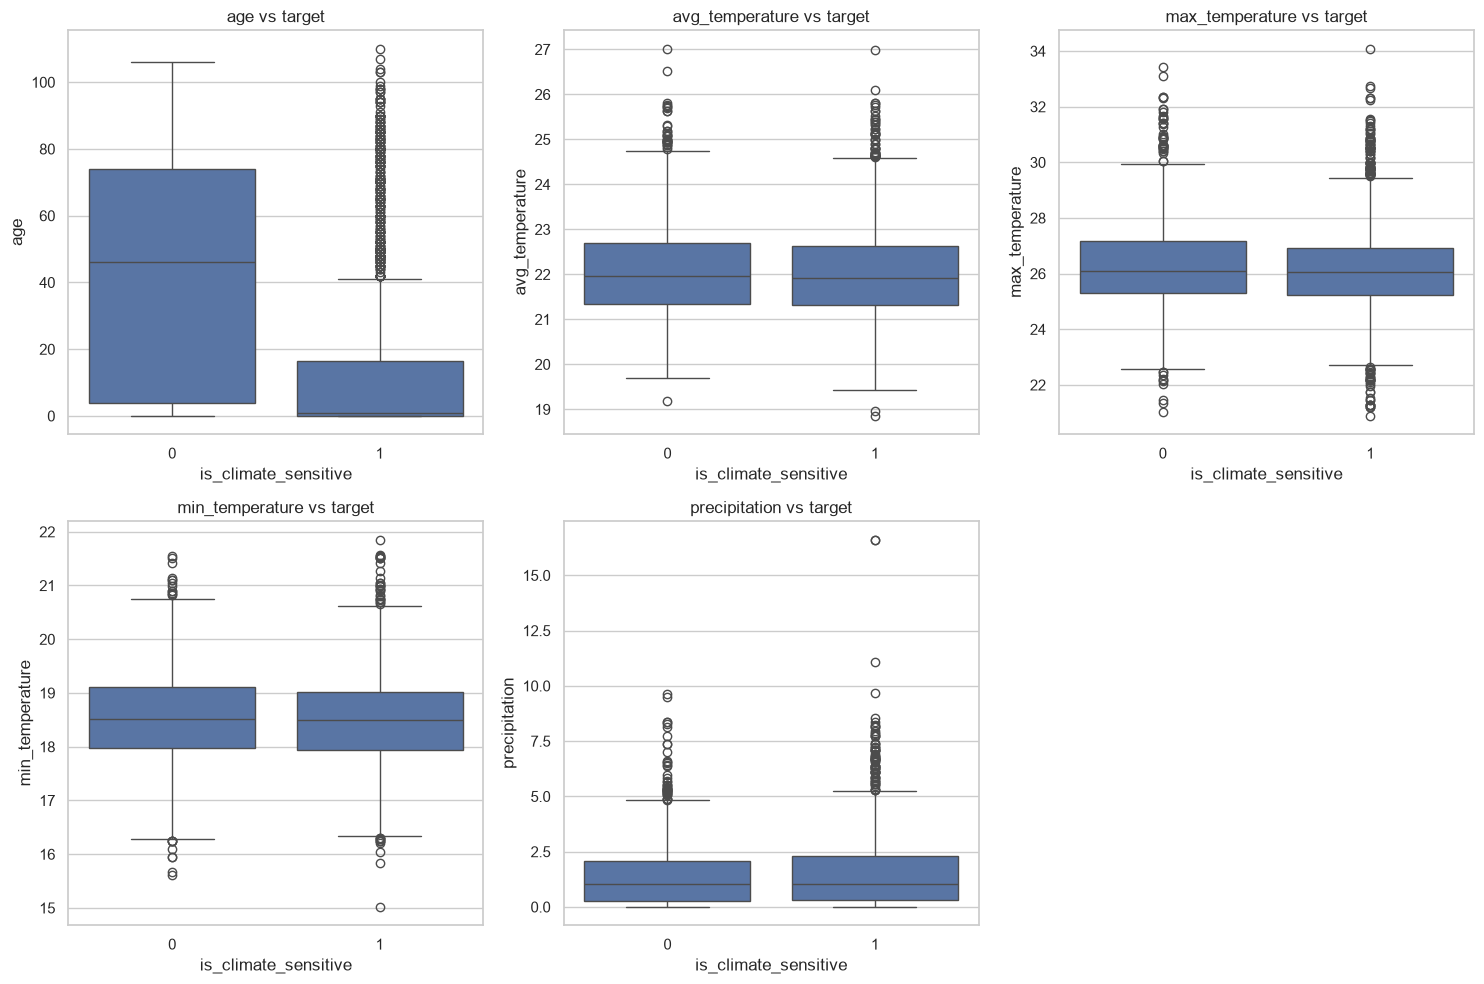

In [8]:
# checking class overlap using boxplots to show the distribution of features split by the target feature
# class overlap (boxplots)
print('--- numerical features vs target (class overlap) ---')
num_cols = ['age', 'avg_temperature', 'max_temperature', 'min_temperature', 'precipitation']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='is_climate_sensitive', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs target')

# remove the empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

--- spearman correlation heatmap ---


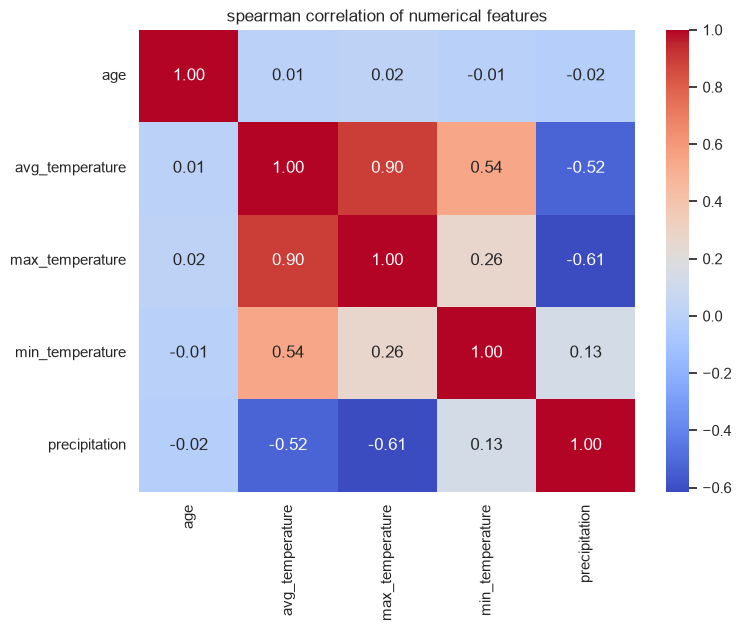

In [9]:
# checking relationships between features in temperature features if they are highly correlated and if the are, it culd casue instabilty in a linear model, so we might drop them
# feature relationships (multicollinearity)
print('--- spearman correlation heatmap ---')
corr = df[num_cols].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('spearman correlation of numerical features')
plt.show()

--- categorical relationships ---


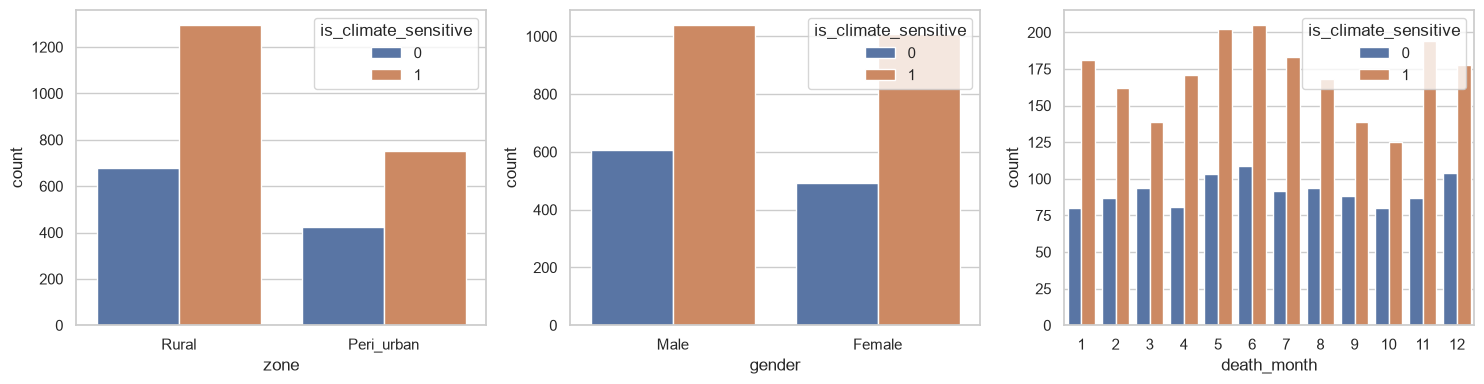

chi-square p-value for zone: 0.3788


In [10]:
# checking if gender, zone features have relationship with climate sensitive deaths to try to map out the deaths whether they are clustered together or distributed randomly across region
# categorical & temporal relationships
print('--- categorical relationships ---')

# extract month
df['death_month'] = pd.to_datetime(df['deathdate']).dt.month

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x='zone', hue='is_climate_sensitive', ax=axes[0])
sns.countplot(data=df, x='gender', hue='is_climate_sensitive', ax=axes[1])
sns.countplot(data=df, x='death_month', hue='is_climate_sensitive', ax=axes[2])
plt.tight_layout()
plt.show()

# chi-square for zone
contingency = pd.crosstab(df['zone'], df['is_climate_sensitive'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f'chi-square p-value for zone: {p:.4f}')

--- geospatial analysis ---


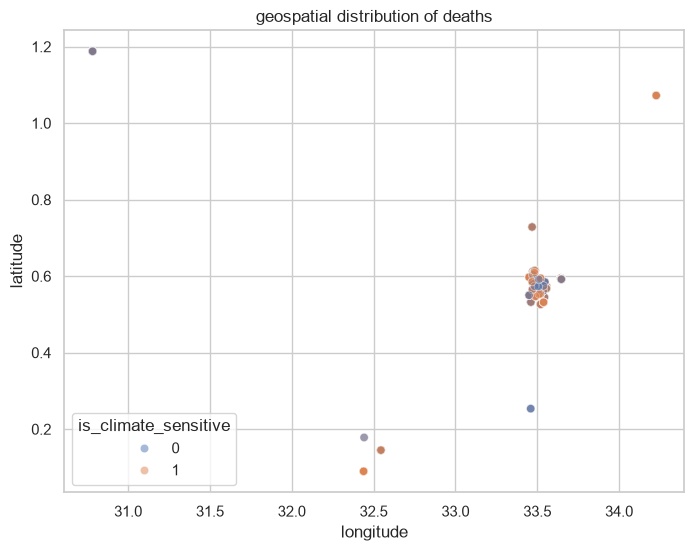

In [11]:
# analysis using lat and long features which could also help to map out deaths in region if they are together closely or scattered away
# geospatial analysis
print('--- geospatial analysis ---')
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='is_climate_sensitive', alpha=0.5)
plt.title('geospatial distribution of deaths')
plt.show()

--- high-dimensional separability (pca) ---


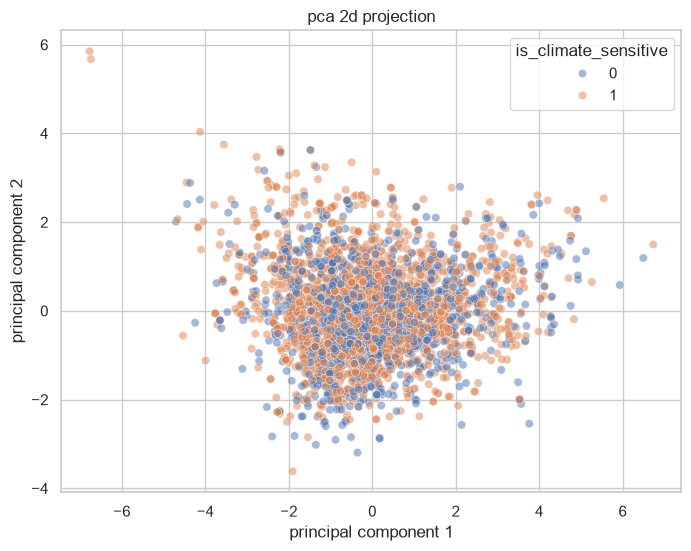

In [12]:
# checking level of class separation which can help us with determine if we will use linear or no linear models or do more feature engineering
# high-dimensional separability (pca)
print('--- high-dimensional separability (pca) ---')
scaler = StandardScaler()
scaled_nums = scaler.fit_transform(df[num_cols])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_nums)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=df['is_climate_sensitive'], alpha=0.5)
plt.title('pca 2d projection')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.show()

---
**insights from extended eda:**
- age is highly predictive because climate-sensitive deaths are mostly infants, so we will rely heavily on this feature.
- temperature variables (avg, min, max) are nearly identical across classes and highly correlated, creating multicollinearity.
- seasonality (months 5, 6, 7, 12) and rural zones show huge spikes in deaths, making them crucial categorical predictors.
- the pca projection shows a massive overlap blob, proving the classes are not linearly separable.

**phase 3 strategy:**
- extract the month from deathdate to capture the strong seasonal effects, then drop the original string column.
- drop the id column as it has no predictive value, and drop location since we already have exact latitude and longitude coordinates.
- apply one-hot encoding to zone, gender, and month so the model treats them as distinct non-ordinal categories.
- skip feature scaling because our chosen tree-based models are completely immune to differences in numerical scales.
- select non-linear tree-based models (like xgboost or random forest) because they easily handle the pca overlap and temperature multicollinearity.